# Lenguaje de Programación Visual / Machine Learning
### Ingeniería Electrónica - Universidad Nacional
**Clase 2: Regresión Lineal y Algoritmos de Optimización**
**basada en CS229 (Stanford) - Prof. Andrew Ng**

---

## 1. Formulación Formal del Problema de Regresión Lineal

### Preámbulo Matemático (Notación CS229)

Sea un conjunto de entrenamiento (training set) de $n$ ejemplos denotado como:
$$\mathcal{S} = \{(x^{(i)}, y^{(i)}); i = 1, \dots, n\}$$

Donde:
- $x^{(i)} \in \mathbb{R}^d$ representa el vector de variables de entrada o atributos (*input features*).
- $y^{(i)} \in \mathbb{R}$ representa la variable objetivo u observación (*target variable*).
- El superíndice $(i)$ denota el índice del ejemplo de entrenamiento (sin confundir con exponenciación).
- El subíndice $j$ denota la componente $j$-ésima del vector de atributos.

#### Convenio del Término Intercepto (*Intercept Term*)
Para simplificar la notación, introducimos la convención de fijar $x_0 = 1$, permitiendo incluir el sesgo (*bias*) $\theta_0$ dentro del vector de parámetros $\theta \in \mathbb{R}^{d+1}$:
$$x^{(i)} = \begin{bmatrix} x_0^{(i)} \\ x_1^{(i)} \\ \vdots \\ x_d^{(i)} \end{bmatrix} \in \mathbb{R}^{d+1}, \quad \text{con } x_0^{(i)} = 1$$

#### Hipótesis del Modelo
Aproximamos la salida $y$ como una función lineal de $x$ llamada **hipótesis** $h_\theta(x)$:
$$h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_d x_d = \sum_{j=0}^d \theta_j x_j = \theta^T x$$

#### Función de Costo de Mínimos Cuadrados Ordinarios (OLS Cost Function)
Para medir la calidad de los parámetros $\theta$, definimos la función de costo $J(\theta)$ que cuantifica qué tan cerca están las predicciones $h_\theta(x^{(i)})$ de los valores reales $y^{(i)}$:
$$J(\theta) = \frac{1}{2} \sum_{i=1}^n \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

El factor $\frac{1}{2}$ se introduce por conveniencia algebraica al tomar derivadas.

=== PRIMEROS 5 REGISTROS DEL DATASET DE VIVIENDAS ===
   Superficie_ft2  Habitaciones  Precio_1000USD
0     2185.798440             2      354.728907
1     4317.642934             4      721.830620
2     3508.377585             5      557.520398
3     3015.036392             2      532.766935
4     1377.268970             2      261.587240


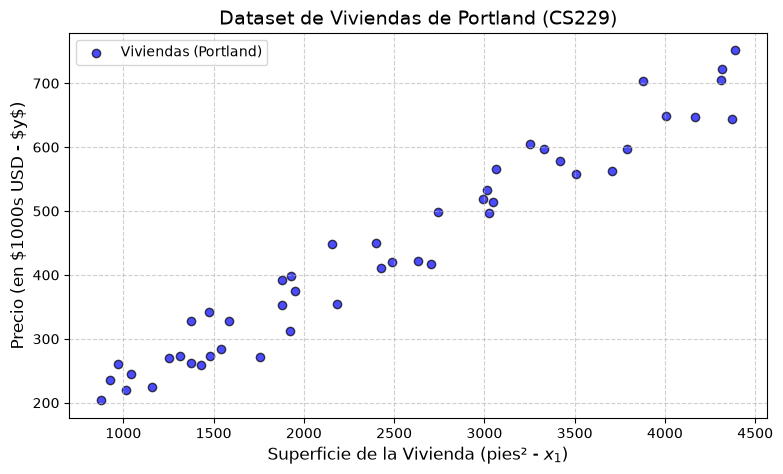

In [1]:
# Script 1: Definición del Dataset de Ejemplo (Precios de Viviendas de Portland) e Hipótesis Inicial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fijar semilla para reproducibilidad
np.random.seed(42)

# Dataset inspirado en el ejemplo clásico de Portland, Oregon (CS229)
# Superficie (pies cuadrados), Número de habitaciones -> Precio (en miles de USD)
n_samples = 47
superficie = np.random.uniform(800, 4500, n_samples)
habitaciones = np.random.randint(1, 6, n_samples)

# Generar precios reales basados en un modelo subyacente con ruido gaussiano
# Precio ($1000s) = 75 + 0.14 * superficie + 15 * habitaciones + ruido
ruido = np.random.normal(0, 25, n_samples)
precio = 75.0 + 0.135 * superficie + 12.0 * habitaciones + ruido

# Crear DataFrame de Pandas
df_housing = pd.DataFrame({
    'Superficie_ft2': superficie,
    'Habitaciones': habitaciones,
    'Precio_1000USD': precio
})

print("=== PRIMEROS 5 REGISTROS DEL DATASET DE VIVIENDAS ===")
print(df_housing.head())

# Visualizar datos: Superficie vs Precio
plt.figure(figsize=(9, 5))
plt.scatter(df_housing['Superficie_ft2'], df_housing['Precio_1000USD'], color='blue', alpha=0.7, edgecolors='k', label='Viviendas (Portland)')
plt.xlabel('Superficie de la Vivienda (pies² - $x_1$)', fontsize=12)
plt.ylabel('Precio (en $1000s USD - $y$)', fontsize=12)
plt.title('Dataset de Viviendas de Portland (CS229)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Definir funciones fundamentales en notación vectorial
def calcular_hipotesis(X, theta):
    """
    Calcula h_theta(x) = X @ theta
    X: Matriz de diseño (n, d+1)
    theta: Vector de parámetros (d+1, 1)
    """
    return X @ theta

def calcular_costo(X, y, theta):
    """
    Calcula J(theta) = 0.5 * sum((h_theta(x^(i)) - y^(i))^2)
    """
    n = len(y)
    predicciones = calcular_hipotesis(X, theta)
    errores = predicciones - y
    return 0.5 * np.sum(errores ** 2)


## 2. El Algoritmo LMS y Batch Gradient Descent (BGD)

### Preámbulo Matemático (Derivación analítica del Gradiente LMS)

Para minimizar la función de costo cuadrático $J(\theta)$, consideramos el algoritmo de búsqueda de **Gradiente Descendente**, el cual parte de un valor inicial $\theta$ y actualiza repetidamente los parámetros en la dirección opuesta al gradiente (máximo descenso):

$$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)$$

donde $\alpha > 0$ es la **tasa de aprendizaje** (*learning rate*).

#### Derivación para una sola muestra $(x, y)$:
$$\begin{aligned}
\frac{\partial}{\partial \theta_j} J(\theta) &= \frac{\partial}{\partial \theta_j} \frac{1}{2} \left( h_\theta(x) - y \right)^2 \\
&= 2 \cdot \frac{1}{2} \left( h_\theta(x) - y \right) \cdot \frac{\partial}{\partial \theta_j} \left( h_\theta(x) - y \right) \\
&= \left( h_\theta(x) - y \right) \cdot \frac{\partial}{\partial \theta_j} \left( \sum_{i=0}^d \theta_i x_i - y \right) \\
&= \left( h_\theta(x) - y \right) x_j
\end{aligned}$$

#### Regla de Actualización LMS (Least Mean Squares / Widrow-Hoff):
Para una única muestra de entrenamiento, la regla de actualización es:
$$\theta_j := \theta_j + \alpha \left( y^{(i)} - h_\theta(x^{(i)}) \right) x_j^{(i)}$$

#### Algoritmo Batch Gradient Descent (BGD):
Al extender la regla sobre las $n$ muestras del dataset de entrenamiento completo, se obtiene el **Gradiente Descendente por Lotes (Batch)**:

$$\text{Repetir hasta convergencia: } \left\{ \theta_j := \theta_j + \alpha \sum_{i=1}^n \left( y^{(i)} - h_\theta(x^{(i)}) \right) x_j^{(i)} \quad (\forall j \in \{0, \dots, d\}) \right\}$$

En notación vectorial estricta:
$$\theta := \theta + \alpha \sum_{i=1}^n \left( y^{(i)} - h_\theta(x^{(i)}) \right) x^{(i)}$$

=== PARÁMETROS OPTIMIZADOS CON BGD ===
theta_0 (Intercepto): 435.6836
theta_1 (Superficie norm): 148.5820
theta_2 (Habitaciones norm): 25.6846
Costo Final J(theta): 11531.8562


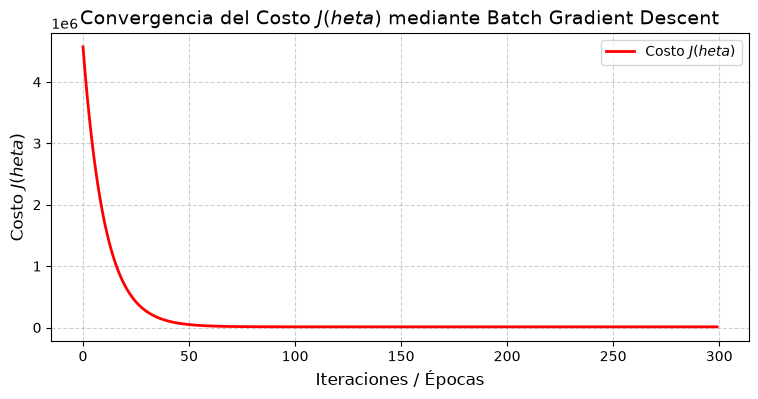

In [2]:
# Script 2: Implementación de Batch Gradient Descent (BGD) con Normalización de Características

# 1. Preparar la Matriz de Atributos X y el Vector de Salidas y
X_raw = df_housing[['Superficie_ft2', 'Habitaciones']].values
y_vec = df_housing['Precio_1000USD'].values.reshape(-1, 1)

# 2. Normalización de Características (Z-score Normalization)
# Es crucial escalar los atributos para garantizar la esfericidad de los contornos de J(theta)
mu_X = np.mean(X_raw, axis=0)
sigma_X = np.std(X_raw, axis=0)
X_norm = (X_raw - mu_X) / sigma_X

# 3. Añadir la columna de unos para el término de intercepto x_0 = 1
n_samples = len(y_vec)
X_mat = np.hstack((np.ones((n_samples, 1)), X_norm))

def batch_gradient_descent(X, y, alpha=0.01, num_iters=400):
    """
    Ejecuta el algoritmo Batch Gradient Descent (BGD) según CS229.
    theta := theta + alpha * sum_i (y^(i) - h_theta(x^(i))) * x^(i)
    """
    n, d_plus_1 = X.shape
    theta = np.zeros((d_plus_1, 1))
    historial_costo = []
    historial_theta = [theta.copy()]
    
    for i in range(num_iters):
        # Predicción actual h_theta(X)
        h = calcular_hipotesis(X, theta)
        
        # Vector de errores: (y - h_theta(x))
        error = y - h
        
        # Actualización de BGD (LMS batch update)
        # theta = theta + alpha * X.T @ error
        theta = theta + alpha * (X.T @ error)
        
        costo = calcular_costo(X, y, theta)
        historial_costo.append(costo)
        historial_theta.append(theta.copy())
        
    return theta, historial_costo, historial_theta

# Ejecutar BGD
alpha = 0.001
num_iters = 300
theta_bgd, historial_costo_bgd, hist_theta_bgd = batch_gradient_descent(X_mat, y_vec, alpha=alpha, num_iters=num_iters)

print("=== PARÁMETROS OPTIMIZADOS CON BGD ===")
print(f"theta_0 (Intercepto): {theta_bgd[0,0]:.4f}")
print(f"theta_1 (Superficie norm): {theta_bgd[1,0]:.4f}")
print(f"theta_2 (Habitaciones norm): {theta_bgd[2,0]:.4f}")
print(f"Costo Final J(theta): {historial_costo_bgd[-1]:.4f}")

# Gráfico de convergencia del Costo J(theta)
plt.figure(figsize=(9, 4))
plt.plot(range(num_iters), historial_costo_bgd, 'r-', linewidth=2, label='Costo $J(\theta)$')
plt.xlabel('Iteraciones / Épocas', fontsize=12)
plt.ylabel('Costo $J(\theta)$', fontsize=12)
plt.title('Convergencia del Costo $J(\theta)$ mediante Batch Gradient Descent', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


## 3. Gradiente Descendente Estocástico (Stochastic Gradient Descent - SGD)

### Preámbulo Matemático (Incremental Gradient Descent)

A diferencia de Batch Gradient Descent (BGD), el cual debe escanear todo el conjunto de entrenamiento de $n$ ejemplos antes de realizar una sola actualización de $\theta$, el **Gradiente Descendente Estocástico (SGD)** (también conocido como *Incremental Gradient Descent*) actualiza los parámetros en cada paso basándose en **un único ejemplo de entrenamiento** $(x^{(i)}, y^{(i)})$.

#### Algoritmo SGD (CS229):
$$\text{Loop } \left\{ \text{for } i = 1 \text{ to } n, \left\{ \theta_j := \theta_j + \alpha \left( y^{(i)} - h_\theta(x^{(i)}) \right) x_j^{(i)}, \quad (\forall j \in \{0, \dots, d\}) \right\} \right\}$$

En notación vectorial para la muestra $i$-ésima:
$$\theta := \theta + \alpha \left( y^{(i)} - h_\theta(x^{(i)}) \right) x^{(i)}$$

#### Comparación Teórica entre BGD y SGD:
- **BGD:** Garantiza la convergencia monótona hacia el mínimo global (ya que $J(\theta)$ es una función cuadrática convexa), pero cada iteración requiere $O(n \cdot d)$ operaciones. Para grandes volúmenes de datos ($n > 10^6$), cada iteración es extremadamente costosa.
- **SGD:** Realiza progresos de inmediato tras inspeccionar cada muestra individual. Aunque oscila alrededor del mínimo global debido a la varianza del gradiente estocástico, en la práctica alcanza una aproximación óptima mucho más rápido que BGD en grandes conjuntos de datos.

=== PARÁMETROS OPTIMIZADOS CON SGD ===
theta_0 (Intercepto): 423.0813
theta_1 (Superficie norm): 143.9557
theta_2 (Habitaciones norm): 27.3529
Costo Final J(theta): 15772.6019


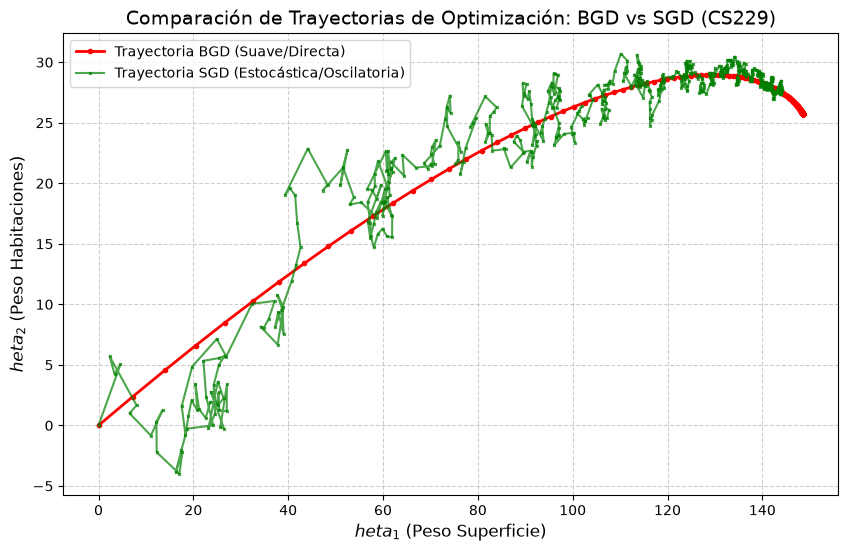

In [3]:
# Script 3: Implementación de Stochastic Gradient Descent (SGD) y Comparación de Trayectorias

def stochastic_gradient_descent(X, y, alpha=0.005, epochs=10):
    """
    Ejecuta el algoritmo Stochastic Gradient Descent (SGD) según CS229.
    Itera muestra por muestra actualizando theta inmediatamente.
    """
    n, d_plus_1 = X.shape
    theta = np.zeros((d_plus_1, 1))
    historial_costo = []
    historial_theta = [theta.copy()]
    
    for epoch in range(epochs):
        # Permutar índices aleatoriamente en cada época
        indices = np.random.permutation(n)
        for idx in indices:
            x_i = X[idx:idx+1, :] # Vector fila (1, d+1)
            y_i = y[idx:idx+1]    # Escalar (1, 1)
            
            # Predicción para la muestra i
            h_i = x_i @ theta
            error_i = y_i - h_i
            
            # Actualización estocástica LMS
            theta = theta + alpha * (x_i.T @ error_i)
            
            # Registrar estado en cada paso estocástico
            historial_theta.append(theta.copy())
            historial_costo.append(calcular_costo(X, y, theta))
            
    return theta, historial_costo, historial_theta

# Ejecutar SGD
epochs_sgd = 15
alpha_sgd = 0.005
theta_sgd, historial_costo_sgd, hist_theta_sgd = stochastic_gradient_descent(X_mat, y_vec, alpha=alpha_sgd, epochs=epochs_sgd)

print("=== PARÁMETROS OPTIMIZADOS CON SGD ===")
print(f"theta_0 (Intercepto): {theta_sgd[0,0]:.4f}")
print(f"theta_1 (Superficie norm): {theta_sgd[1,0]:.4f}")
print(f"theta_2 (Habitaciones norm): {theta_sgd[2,0]:.4f}")
print(f"Costo Final J(theta): {historial_costo_sgd[-1]:.4f}")

# Visualizar la trayectoria de convergencia en el espacio de parámetros (theta_1 vs theta_2)
bgd_t1 = [t[1,0] for t in hist_theta_bgd]
bgd_t2 = [t[2,0] for t in hist_theta_bgd]

sgd_t1 = [t[1,0] for t in hist_theta_sgd]
sgd_t2 = [t[2,0] for t in hist_theta_sgd]

plt.figure(figsize=(10, 6))
plt.plot(bgd_t1, bgd_t2, 'r-o', markersize=3, label='Trayectoria BGD (Suave/Directa)', linewidth=2)
plt.plot(sgd_t1, sgd_t2, 'g-x', markersize=2, label='Trayectoria SGD (Estocástica/Oscilatoria)', alpha=0.7)
plt.xlabel('$\theta_1$ (Peso Superficie)', fontsize=12)
plt.ylabel('$\theta_2$ (Peso Habitaciones)', fontsize=12)
plt.title('Comparación de Trayectorias de Optimización: BGD vs SGD (CS229)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


## 4. Solución en Forma Cerrada: Las Ecuaciones Normales

### Preámbulo Matemático (Derivación mediante Cálculo Matricial)

En lugar de minimizar $J(\theta)$ mediante algoritmos iterativos, podemos resolver el problema analíticamente calculando la derivada matricial de $J(\theta)$ con respecto a $\theta$ e igualándola a cero.

#### 1. Definición de la Matriz de Diseño $X$ y el Vector de Objetivos $\vec{y}$:
Dadas las $n$ muestras de entrenamiento, construimos la matriz de diseño $X \in \mathbb{R}^{n \times (d+1)}$ cuyas filas son los vectores transpuestos $(x^{(i)})^T$:
$$X = \begin{bmatrix} - (x^{(1)})^T - \\ - (x^{(2)})^T - \\ \vdots \\ - (x^{(n)})^T - \end{bmatrix}_{n \times (d+1)}, \quad \vec{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(n)} \end{bmatrix}_{n \times 1}$$

Dado que $h_\theta(x^{(i)}) = (x^{(i)})^T \theta$, el producto $X \theta$ resulta en:
$$X \theta - \vec{y} = \begin{bmatrix} (x^{(1)})^T \theta \\ \vdots \\ (x^{(n)})^T \theta \end{bmatrix} - \begin{bmatrix} y^{(1)} \\ \vdots \\ y^{(n)} \end{bmatrix} = \begin{bmatrix} h_\theta(x^{(1)}) - y^{(1)} \\ \vdots \\ h_\theta(x^{(n)}) - y^{(n)} \end{bmatrix}$$

#### 2. Reescritura de la Función de Costo en Forma Vectorial:
Utilizando la propiedad vectorial $z^T z = \sum_i z_i^2$, expresamos $J(\theta)$ como:
$$J(\theta) = \frac{1}{2} (X \theta - \vec{y})^T (X \theta - \vec{y})$$

#### 3. Derivada del Gradiente Matricial $\nabla_\theta J(\theta)$:
Expandiendo el producto interno:
$$\begin{aligned}
J(\theta) &= \frac{1}{2} \left( (X\theta)^T - \vec{y}^T \right) (X\theta - \vec{y}) \\
&= \frac{1}{2} \left( \theta^T X^T X \theta - \theta^T X^T \vec{y} - \vec{y}^T X \theta + \vec{y}^T \vec{y} \right) \\
&= \frac{1}{2} \left( \theta^T (X^T X) \theta - 2 (X^T \vec{y})^T \theta + \vec{y}^T \vec{y} \right)
\end{aligned}$$

Usando los hechos del cálculo matricial de CS229: $\nabla_z (b^T z) = b$ y $\nabla_z (z^T A z) = 2 A z$ (para $A$ simétrica):
$$\nabla_\theta J(\theta) = \frac{1}{2} \left( 2 X^T X \theta - 2 X^T \vec{y} \right) = X^T X \theta - X^T \vec{y}$$

#### 4. Obtención de las Ecuaciones Normales:
Igualando el gradiente a cero (punto crítico):
$$X^T X \theta = X^T \vec{y} \implies \theta = (X^T X)^{-1} X^T \vec{y}$$

*Nota:* Esta solución requiere que la matriz $X^T X$ sea invertible (no singular).

In [4]:
# Script 4: Solución en Forma Cerrada mediante Ecuaciones Normales y Comparación con Scikit-Learn
from sklearn.linear_model import LinearRegression

def ecuaciones_normales(X, y):
    """
    Calcula theta óptimo en forma cerrada: theta = (X^T X)^(-1) X^T y
    """
    return np.linalg.inv(X.T @ X) @ X.T @ y

# 1. Solución Analítica mediante Ecuaciones Normales (con características normalizadas)
theta_norm_eq = ecuaciones_normales(X_mat, y_vec)
costo_norm_eq = calcular_costo(X_mat, y_vec, theta_norm_eq)

# 2. Solución con Scikit-Learn para Validación Crucial de Ingeniería
model_sklearn = LinearRegression(fit_intercept=False)
model_sklearn.fit(X_mat, y_vec)
theta_sklearn = model_sklearn.coef_.T

# 3. Tabla Comparativa de Resultados entre Enfoques
tabla_comparativa = pd.DataFrame({
    'Parámetro': ['theta_0 (Intercepto)', 'theta_1 (Superficie)', 'theta_2 (Habitaciones)', 'Costo Final J(theta)'],
    'BGD (Iterativo)': [theta_bgd[0,0], theta_bgd[1,0], theta_bgd[2,0], historial_costo_bgd[-1]],
    'SGD (Estocástico)': [theta_sgd[0,0], theta_sgd[1,0], theta_sgd[2,0], historial_costo_sgd[-1]],
    'Ecuaciones Normales': [theta_norm_eq[0,0], theta_norm_eq[1,0], theta_norm_eq[2,0], costo_norm_eq],
    'Scikit-Learn': [theta_sklearn[0,0], theta_sklearn[1,0], theta_sklearn[2,0], calcular_costo(X_mat, y_vec, theta_sklearn)]
})

print("=== TABLA COMPARATIVA DE PARÁMETROS Y COSTO $J(\theta)$ ===")
print(tabla_comparativa.to_string(index=False))


=== TABLA COMPARATIVA DE PARÁMETROS Y COSTO $J(	heta)$ ===
             Parámetro  BGD (Iterativo)  SGD (Estocástico)  Ecuaciones Normales  Scikit-Learn
  theta_0 (Intercepto)       435.683575         423.081309           435.683807    435.683807
  theta_1 (Superficie)       148.582029         143.955712           148.582409    148.582409
theta_2 (Habitaciones)        25.684645          27.352927            25.684272     25.684272
  Costo Final J(theta)     11531.856162       15772.601897         11531.856155  11531.856155


## 5. Interpretación Probabilística de Mínimos Cuadrados (MLE)

### Preámbulo Matemático (Máxima Verosimilitud y Ruido Gaussiano)

¿Por qué la función de costo de Mínimos Cuadrados Ordinarios $J(\theta) = \frac{1}{2} \sum (h_\theta(x) - y)^2$ es una elección natural e intuitiva en regresión?

Asumamos que la variable objetivo $y^{(i)}$ y los atributos $x^{(i)}$ están relacionados mediante la ecuación:
$$y^{(i)} = \theta^T x^{(i)} + \epsilon^{(i)}$$

donde $\epsilon^{(i)}$ representa un término de error aleatorio u omisión de variables que satisface el supuesto de ser **Independiente e Idénticamente Distribuido (I.I.D.)** según una distribución Normal (Gaussiana) con media cero y varianza $\sigma^2$:
$$\epsilon^{(i)} \sim \mathcal{N}(0, \sigma^2)$$

La función de densidad de probabilidad de $\epsilon^{(i)}$ es:
$$p(\epsilon^{(i)}) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left( -\frac{(\epsilon^{(i)})^2}{2\sigma^2} \right)$$

Esto implica que la distribución condicional de $y^{(i)}$ dado $x^{(i)}$ parametrizada por $\theta$ es:
$$p(y^{(i)} | x^{(i)}; \theta) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left( -\frac{\left( y^{(i)} - \theta^T x^{(i)} \right)^2}{2\sigma^2} \right)$$

#### Función de Verosimilitud (Likelihood Function $L(\theta)$):
Dado que los errores son independientes, la verosimilitud conjunta del dataset completo $X, \vec{y}$ es el producto de las probabilidades individuales:
$$L(\theta) = L(\theta; X, \vec{y}) = \prod_{i=1}^n p(y^{(i)} | x^{(i)}; \theta) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi}\sigma} \exp\left( -\frac{\left( y^{(i)} - \theta^T x^{(i)} \right)^2}{2\sigma^2} \right)$$

#### Log-Verosimilitud (Log-Likelihood $\ell(\theta)$):
Para simplificar las derivadas, aplicamos el logaritmo natural $\ell(\theta) = \log L(\theta)$:
$$\begin{aligned}
\ell(\theta) &= \sum_{i=1}^n \log \left[ \frac{1}{\sqrt{2\pi}\sigma} \exp\left( -\frac{\left( y^{(i)} - \theta^T x^{(i)} \right)^2}{2\sigma^2} \right) \right] \\
&= n \log \left( \frac{1}{\sqrt{2\pi}\sigma} \right) - \frac{1}{\sigma^2} \cdot \frac{1}{2} \sum_{i=1}^n \left( y^{(i)} - \theta^T x^{(i)} \right)^2
\end{aligned}$$

#### Conclusión Fundamental de CS229:
Maximizar la Log-Verosimilitud $\ell(\theta)$ con respecto a $\theta$ equivale exactamente a **minimizar**:
$$\frac{1}{2} \sum_{i=1}^n \left( y^{(i)} - \theta^T x^{(i)} \right)^2 = J(\theta)$$

Por lo tanto, los **Mínimos Cuadrados Ordinarios (OLS)** derivan naturalmente como la **Estimación de Máxima Verosimilitud (MLE)** bajo el supuesto de ruido gaussiano.

<>:39: SyntaxWarning: invalid escape sequence '\e'
<>:40: SyntaxWarning: invalid escape sequence '\e'
<>:39: SyntaxWarning: invalid escape sequence '\e'
<>:40: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Carlos Benitez\AppData\Local\Temp\ipykernel_15288\2852584867.py:39: SyntaxWarning: invalid escape sequence '\e'
  ax2.set_ylabel('Log-Verosimilitud $\ell(\theta)$', color=color, fontsize=12)
C:\Users\Carlos Benitez\AppData\Local\Temp\ipykernel_15288\2852584867.py:40: SyntaxWarning: invalid escape sequence '\e'
  ax2.plot(t1_vals, log_liks, color=color, linestyle='--', linewidth=2, label='Log-Verosimilitud $\ell(\theta)$ (Maximizar)')


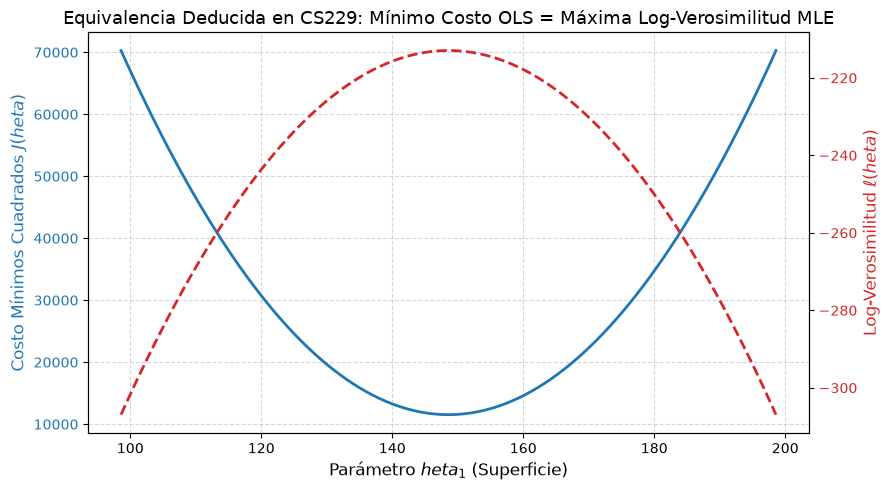

In [5]:
# Script 5: Demostración Empírica de la Equivalencia entre Máxima Verosimilitud (MLE) y Mínimos Cuadrados

def log_verosimilitud(X, y, theta, sigma=25.0):
    """
    Calcula la Log-Verosimilitud l(theta) bajo el supuesto Gaussiano N(0, sigma^2).
    """
    n = len(y)
    h = calcular_hipotesis(X, theta)
    costo_OLS = 0.5 * np.sum((y - h) ** 2)
    
    constante_term = n * np.log(1.0 / (np.sqrt(2 * np.pi) * sigma))
    log_likelihood = constante_term - (1.0 / (sigma ** 2)) * costo_OLS
    return log_likelihood

# Barrido de theta_1 (Superficie) manteniendo los otros parámetros fijos
theta_base = theta_norm_eq.copy()
t1_vals = np.linspace(theta_base[1,0] - 50, theta_base[1,0] + 50, 100)

costos_vals = []
log_liks = []

for t1 in t1_vals:
    t_temp = theta_base.copy()
    t_temp[1,0] = t1
    costos_vals.append(calcular_costo(X_mat, y_vec, t_temp))
    log_liks.append(log_verosimilitud(X_mat, y_vec, t_temp))

fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:blue'
ax1.set_xlabel('Parámetro $\theta_1$ (Superficie)', fontsize=12)
ax1.set_ylabel('Costo Mínimos Cuadrados $J(\theta)$', color=color, fontsize=12)
ax1.plot(t1_vals, costos_vals, color=color, linewidth=2, label='Costo $J(\theta)$ (Minimizar)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Log-Verosimilitud $\ell(\theta)$', color=color, fontsize=12)
ax2.plot(t1_vals, log_liks, color=color, linestyle='--', linewidth=2, label='Log-Verosimilitud $\ell(\theta)$ (Maximizar)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Equivalencia Deducida en CS229: Mínimo Costo OLS = Máxima Log-Verosimilitud MLE', fontsize=13)
fig.tight_layout()
plt.show()


## 6. Regresión Lineal Ponderada Localmente (Locally Weighted Linear Regression - LWR)

### Preámbulo Matemático (Algoritmo No Paramétrico)

En la regresión lineal estándar (algoritmo paramétrico), ajustamos una sola vez los parámetros $\theta$ y luego podemos descartar el conjunto de datos de entrenamiento para realizar prediccionesfuturas. Sin embargo, cuando la relación entre $x$ y $y$ es no lineal complejos, un modelo lineal paramétrico sufre de **underfitting**.

**Locally Weighted Linear Regression (LWR)** es un algoritmo **no paramétrico** donde, para realizar una predicción en un punto de consulta dado $x$ (*query point*), el algoritmo pondera a los vecinos de entrenamiento dándoles mayor relevancia a los puntos cercanos a $x$.

#### Procedimiento de LWR para evaluar $h(x)$ en un punto de consulta $x$:
1. Ajustar $\theta$ para **minimizar** la función de costo ponderada:
   $$J(\theta) = \sum_{i=1}^n w^{(i)} \left( y^{(i)} - \theta^T x^{(i)} \right)^2$$
2. Retornar la predicción evaluada en el punto: $h(x) = \theta^T x$.

#### Elección Estándar de los Pesos $w^{(i)}$ (Kernel Gaussiano):
$$w^{(i)} = \exp\left( -\frac{\left( x^{(i)} - x \right)^2}{2\tau^2} \right)$$

Donde:
- Si $|x^{(i)} - x|$ es pequeño, $w^{(i)} \approx 1$ (el ejemplo influye fuertemente en la estimación de $\theta$).
- Si $|x^{(i)} - x|$ es grande, $w^{(i)} \approx 0$ (el ejemplo es ignorado en el ajuste local).
- $\tau$ es el **parámetro de ancho de banda** (*bandwidth parameter*), el cual controla qué tan rápido cae el peso de un ejemplo con la distancia al punto de consulta $x$.

#### Solución Analítica Matricial de LWR:
Definiendo la matriz diagonal de pesos $W \in \mathbb{R}^{n \times n}$ con $W_{ii} = w^{(i)}$, la solución de forma cerrada es:
$$\theta = (X^T W X)^{-1} X^T W \vec{y}$$

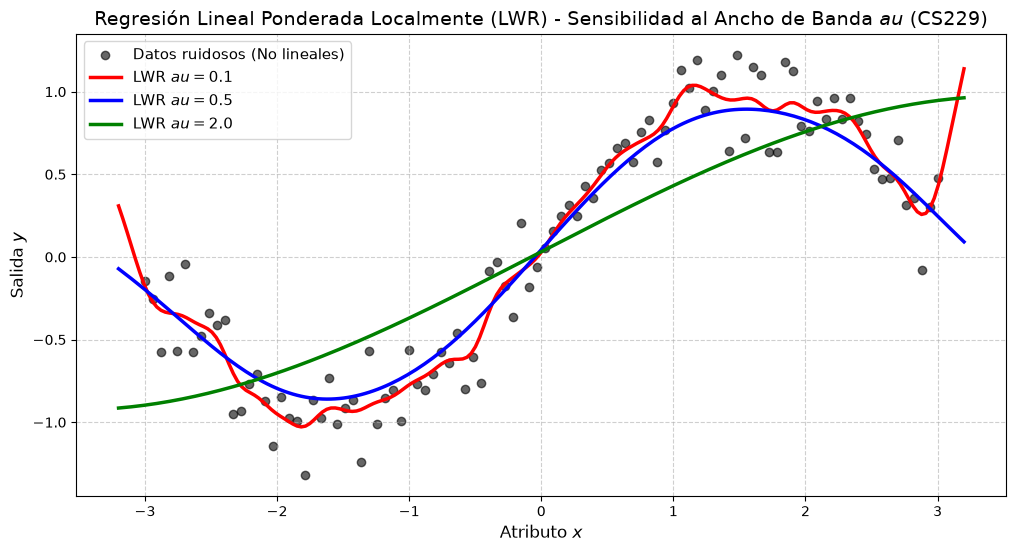

In [6]:
# Script 6: Implementación de Locally Weighted Linear Regression (LWR) y Efecto del Ancho de Banda (tau)
# Generar un dataset unidimensional no lineal sintético para demostrar LWR
X_nolineal = np.linspace(-3, 3, 100)
y_nolineal = np.sin(X_nolineal) + np.random.normal(0, 0.15, 100)

# Matriz de diseño con intercepto x_0 = 1
X_lwr_mat = np.column_stack((np.ones_like(X_nolineal), X_nolineal))

def predict_lwr_point(x_query, X_mat, y_vec, tau):
    """
    Calcula la predicción h(x_query) usando LWR con ancho de banda tau.
    theta = (X^T W X)^(-1) X^T W y
    """
    n = X_mat.shape[0]
    # Calcular vector de pesos w^(i) = exp(- (x^(i) - x_query)^2 / (2 * tau^2))
    # x_query es el punto escalar o vector de atributos sin intercepto
    distancias_cuadradas = np.sum((X_mat[:, 1:] - x_query)**2, axis=1)
    weights = np.exp(-distancias_cuadradas / (2 * (tau ** 2)))
    
    # Matriz de ponderación diagonal W
    W = np.diag(weights)
    
    # Solución en forma cerrada para el punto local: theta = (X^T W X)^(-1) X^T W y
    theta_local = np.linalg.inv(X_mat.T @ W @ X_mat) @ X_mat.T @ W @ y_vec
    
    # Predicción en x_query
    x_query_vec = np.array([1.0, x_query])
    return x_query_vec @ theta_local

# Evaluar LWR sobre una malla de puntos de prueba para distintos valores de tau
x_test_grid = np.linspace(-3.2, 3.2, 200)
taus = [0.1, 0.5, 2.0]

plt.figure(figsize=(12, 6))
plt.scatter(X_nolineal, y_nolineal, color='black', alpha=0.6, label='Datos ruidosos (No lineales)')

colores = ['red', 'blue', 'green']
for tau, col in zip(taus, colores):
    y_pred_lwr = [predict_lwr_point(xq, X_lwr_mat, y_nolineal, tau) for xq in x_test_grid]
    plt.plot(x_test_grid, y_pred_lwr, color=col, linewidth=2.5, label=f'LWR $\tau = {tau}$')

plt.xlabel('Atributo $x$', fontsize=12)
plt.ylabel('Salida $y$', fontsize=12)
plt.title('Regresión Lineal Ponderada Localmente (LWR) - Sensibilidad al Ancho de Banda $\tau$ (CS229)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()


## 7. Conclusiones y Resumen Comparativo de Algoritmos

En este cuaderno interactivo hemos implementado y validado los algoritmos fundamentales del **Capítulo 1 de CS229 (Andrew Ng)**:

| Algoritmo | Tipo | Complejidad por Iteración / Paso | Requerimiento de Memoria | Sensibilidad a Tamaño $n$ | Hiperparámetros Clave |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Batch Gradient Descent (BGD)** | Iterativo Paramétrico | $O(n \cdot d)$ | $O(n \cdot d)$ | Regular en datasets masivos ($n \gg 10^6$) | Learning rate $\alpha$, # Iteraciones |
| **Stochastic Gradient Descent (SGD)** | Iterativo Paramétrico | $O(d)$ | $O(d)$ | Excelente en datasets masivos | Learning rate $\alpha$, Épocas |
| **Ecuaciones Normales** | Analítico Paramétrico | $O(d^3 + n d^2)$ | $O(n d + d^2)$ | Costoso si $d > 10^4$ (inversión matricial) | Ninguno (Solución exacta en forma cerrada) |
| **Locally Weighted Regression (LWR)** | No Paramétrico | $O(n \cdot d^3)$ por predicción | $O(n \cdot d)$ (Requiere almacenar todo $\mathcal{S}$) | Requiere todo el dataset en memoria | Ancho de banda $\tau$ |

### Conclusión General para Ingeniería
1. **BGD** es ideal para problemas de tamaño moderado donde se requiere una convergencia monótona y controlada.
2. **SGD** es la piedra angular del aprendizaje profundo (*Deep Learning*) debido a su bajo costo por actualización y alta velocidad en grandes volúmenes de datos.
3. **Ecuaciones Normales** proporcionan el óptimo global instantáneo sin necesidad de ajustar tasas de aprendizaje cuando la dimensión $d$ es pequeña o moderada.
4. **LWR** es una herramienta poderosa para ajustar manifolds no lineales complejos sin realizar *feature engineering* explícito, a costa de retener todo el dataset durante la inferencia.